## Исследование сортировки 
#### **(20 баллов)**
## 4 вариант

---

Изучите сортировку Шелла и реализуйте ее в виде функции `shell_sort(some_list)`.

Функция принимает список и сортирует его по возрастанию. 

---

##### **Объяснение сортировки Шелла**
(с сайта [geek for geeks](https://www.geeksforgeeks.org/python/python-program-for-shellsort/), переводила вручную)

- Сортировка Шелла это улучшение над Сортировки Вставками. 
    - Вместо сравнивания соседних элементов, она сравнивает далёкие элементы с определённым шагом
    - Шаг продолжает уменьшаться до тех пор, пока не достигнет 1, => сортировка завершена.
    - Это позволяет элементам быстрее перемещаться на соответствующие позиции 

##### **Шаги алгоритма**
1. Шаг = половина длинны массива (n/2)
2. Разбивка массива на подсписки, каждый разделён шагом
3. Выполнить сортировку вставками внутри подписков
4. Уменьшить размер шага и повторять сортировку пока шаг не станет 0
5. Остановиться когда массив полностью отсортирован

##### Пример
- Возьмём небольшой список, напрмер \[9, 1, 5, 3\].
- По шагам:
    - Изначальный список = \[9, 1, 5, 3\].
    - Число элементов = 4;
        - => начальный шаг = 2 (n/2)
    - **Проход 1.** (шаг = 2)
        - сравнить `arr[0] = [9]` и `arr[2] = [5]`:
            - Т.к. 9 > 5: => меняем местами => `[5, 1, 9, 3]`
        - сравнить `arr[1] = [1]` и `arr[3] =[3]`:
            - Т.к. 1 < 3 => не меняем местами => `[5, 1, 9, 3]`
        - Проход завершён: `[5, 1, 9, 3]`
    - **Проход 2.** (шаг = 1)
        - Сравнить `arr[1] = 1 и arr[0] = 5:`
            - Т.к. 1 < 5 => меняем => `[1, 5, 9, 3]`
        - Сравнить `arr[2] = 9 и arr[1] = 5:`
            - Т.к. 9 > 5 => не меняем.
        - Сравнить `arr[3] = 3 и arr[2] = 9:`
            - Т.к. 3 < 9 => меняем => `[1, 5, 3, 9]`
        - Сравнить `arr[2] = 3 и arr[1] = 5:`
            - Т.к. 3 < 5 => меняем => `[1, 3, 5, 9]`
        - Проход завершён: `[1, 3, 5, 9]`
    - **Алгоритм завершён.**

    ##### **Реализация на Python**
    - Используется последовательность Ciura: заранее определенная последовательность шагов
        - основанная на экспериментальных результатах (701, 301, 132, 57, 23, 10, 4, 1).
        - Массив сначала сортируется с использованием больших шагов и прогрессивно уменьшает шаг,
        - гарантируя что элементы приближаются к своим правильным положениям быстрее.

**ПРИМЕЧАНИЕ:** 
- КОД НИЖЕ (реализация) взята [отсюда](https://www.w3tutorials.net/blog/fastest-gap-sequence-for-shell-sort/).
- И по этой же ^ ссылке использована формула для рекуррентного продолжения Ciura: 
    - `gap[i] = floor(gap[i-1] * 2.25)`


In [10]:
# ПРИМ.: комментарии перевела

def generate_ciura_sequence(n):
    """Generate Ciura's gap sequence up to gaps < n."""
    # Эмпирически выведенные Циурой элементы последовательности:
    ciura_core = [1, 4, 10, 23, 57, 132, 301, 701, 1750]
    # Фильтруем, оставляя только шаги < n
    gaps = [g for g in ciura_core if g < n]
    # Разворачиваем чтобы использовать от большего к меньшему
    return gaps[::-1]
 
def shell_sort_EXAMPLE(arr):
    n = len(arr)
    # Генерируем шаги Циуры с учётом размера нашего массива
    gaps = generate_ciura_sequence(n)
    
    for gap in gaps:
        # Выполняем сортировку вставками для элементов удалённых друг от друга на 'gap'
        for i in range(gap, n):
            temp = arr[i]     # запоминаем текущий элемент
            j = i             # и его индекс
            # Переместить ранее отсортированные элементы вправо, пока текущий элемент
            # (который мы запомнили в temp) не будет на своём месте
            while j >= gap and arr[j - gap] > temp:
                arr[j] = arr[j - gap]
                j -= gap
            arr[j] = temp
    return arr
 
# Пример использования
unsorted_array = [64, 34, 25, 12, 22, 11, 90]
sorted_array = shell_sort_EXAMPLE(unsorted_array)
print("Sorted array:", sorted_array)  # Вывод: [11, 12, 22, 25, 34, 64, 90]


Sorted array: [11, 12, 22, 25, 34, 64, 90]


--- 
### **ЗАДАНИЯ СЕМЕСТРОВОЙ РАБОТЫ**
---

Сначала реализуем сортировку (отредактировала код выше, добавила рекуррентное расширение последовательности Циуры)

In [11]:
import math
import random
import time

def gen_ciura_sequence(n):
    ciura_core = [1, 4, 10, 23, 57, 132, 301, 701, 1750]
    if n <= 1750:
        gaps = [g for g in ciura_core if g < n]
    else:
        gaps = ciura_core.copy()
        while gaps[-1] < n:
            gaps.append (math.floor(gaps[-1] * 2.25))
    
    return gaps[::-1]

def shell_sort(some_list):
    n = len(some_list)
    gaps = gen_ciura_sequence(n)
    
    for gap in gaps:
        for i in range(gap, n):
            temp = some_list[i]
            j = i
            while j >= gap and some_list[j - gap] > temp:
                some_list[j] = some_list[j - gap]
                j -= gap
            some_list[j] = temp
    return some_list

# Тест на 10.000 случайных чисел
unsorted_array = [random.randint(1, 100000) for _ in range(10000)]
print(f"Создан массив из {len(unsorted_array)} элементов")

start = time.time()
sorted_array = shell_sort(unsorted_array)
end = time.time()

print(f"Время сортировки: {end - start:.4f} сек")
print("Первые 10:", sorted_array[:10])
print("Последние 10:", sorted_array[-10:])
print("Отсортировано?", sorted_array == sorted(sorted_array))  # True

Создан массив из 10000 элементов
Время сортировки: 0.0314 сек
Первые 10: [4, 11, 22, 22, 23, 34, 42, 60, 64, 65]
Последние 10: [99900, 99920, 99928, 99933, 99946, 99949, 99966, 99981, 99982, 99988]
Отсортировано? True


---

1. **(2 балла)**
- Выпишите результаты всех итераций сортировки Шелла с шагами 7, 5, 3 и 1 
- на списке [16, 15, 14, 13, 12, 11, 10, 9, 8, 7, 6, 5, 4, 3, 2, 1]. 
- Сколько сравнений было выполнено? 

In [12]:
# пишем ещё одну сортировку
def shell_sort_w_print(arr, gaps):
    n = len(arr)
    comparisons = 0
    
    print("Исходный:", arr)
    for gap in gaps:
        print(f"\n-------------- Gap = {gap} -----------------")
        for i in range(gap, n):
            temp = arr[i]
            j = i
            additional_print = 0
            while j >= gap and arr[j - gap] > temp:
                comparisons += 1
                print(f"Сравнение №{comparisons}: arr[{j-gap}] = {arr[j-gap]} > {temp}")
                additional_print = 1
                arr[j] = arr[j - gap]
                j -= gap
            arr[j] = temp
            if additional_print:
                print(f"\tМеняем: ", arr)
        print(f"После gap {gap}:", arr)
    
    print(f"\nИтого сравнений: {comparisons}")
    return arr, comparisons

# Задание
arr = [16, 15, 14, 13, 12, 11, 10, 9, 8, 7, 6, 5, 4, 3, 2, 1]
gaps = [7, 5, 3, 1]
result, cmp_count = shell_sort_w_print(arr.copy(), gaps)

Исходный: [16, 15, 14, 13, 12, 11, 10, 9, 8, 7, 6, 5, 4, 3, 2, 1]

-------------- Gap = 7 -----------------
Сравнение №1: arr[0] = 16 > 9
	Меняем:  [9, 15, 14, 13, 12, 11, 10, 16, 8, 7, 6, 5, 4, 3, 2, 1]
Сравнение №2: arr[1] = 15 > 8
	Меняем:  [9, 8, 14, 13, 12, 11, 10, 16, 15, 7, 6, 5, 4, 3, 2, 1]
Сравнение №3: arr[2] = 14 > 7
	Меняем:  [9, 8, 7, 13, 12, 11, 10, 16, 15, 14, 6, 5, 4, 3, 2, 1]
Сравнение №4: arr[3] = 13 > 6
	Меняем:  [9, 8, 7, 6, 12, 11, 10, 16, 15, 14, 13, 5, 4, 3, 2, 1]
Сравнение №5: arr[4] = 12 > 5
	Меняем:  [9, 8, 7, 6, 5, 11, 10, 16, 15, 14, 13, 12, 4, 3, 2, 1]
Сравнение №6: arr[5] = 11 > 4
	Меняем:  [9, 8, 7, 6, 5, 4, 10, 16, 15, 14, 13, 12, 11, 3, 2, 1]
Сравнение №7: arr[6] = 10 > 3
	Меняем:  [9, 8, 7, 6, 5, 4, 3, 16, 15, 14, 13, 12, 11, 10, 2, 1]
Сравнение №8: arr[7] = 16 > 2
Сравнение №9: arr[0] = 9 > 2
	Меняем:  [2, 8, 7, 6, 5, 4, 3, 9, 15, 14, 13, 12, 11, 10, 16, 1]
Сравнение №10: arr[8] = 15 > 1
Сравнение №11: arr[1] = 8 > 1
	Меняем:  [2, 1, 7, 6, 5, 4, 3, 9,

---

2. **(2 балла)**
- Выпишите результаты всех итераций сортировки Шелла с шагами 8, 4, 2 и 1
- на списке [16, 15, 14, 13, 12, 11, 10, 9, 8, 7, 6, 5, 4, 3, 2, 1]
- Сколько сравнений было выполнено?

In [13]:
arr = [16, 15, 14, 13, 12, 11, 10, 9, 8, 7, 6, 5, 4, 3, 2, 1]
gaps = [8, 4, 2, 1]
result, cmp_count = shell_sort_w_print(arr.copy(), gaps)

Исходный: [16, 15, 14, 13, 12, 11, 10, 9, 8, 7, 6, 5, 4, 3, 2, 1]

-------------- Gap = 8 -----------------
Сравнение №1: arr[0] = 16 > 8
	Меняем:  [8, 15, 14, 13, 12, 11, 10, 9, 16, 7, 6, 5, 4, 3, 2, 1]
Сравнение №2: arr[1] = 15 > 7
	Меняем:  [8, 7, 14, 13, 12, 11, 10, 9, 16, 15, 6, 5, 4, 3, 2, 1]
Сравнение №3: arr[2] = 14 > 6
	Меняем:  [8, 7, 6, 13, 12, 11, 10, 9, 16, 15, 14, 5, 4, 3, 2, 1]
Сравнение №4: arr[3] = 13 > 5
	Меняем:  [8, 7, 6, 5, 12, 11, 10, 9, 16, 15, 14, 13, 4, 3, 2, 1]
Сравнение №5: arr[4] = 12 > 4
	Меняем:  [8, 7, 6, 5, 4, 11, 10, 9, 16, 15, 14, 13, 12, 3, 2, 1]
Сравнение №6: arr[5] = 11 > 3
	Меняем:  [8, 7, 6, 5, 4, 3, 10, 9, 16, 15, 14, 13, 12, 11, 2, 1]
Сравнение №7: arr[6] = 10 > 2
	Меняем:  [8, 7, 6, 5, 4, 3, 2, 9, 16, 15, 14, 13, 12, 11, 10, 1]
Сравнение №8: arr[7] = 9 > 1
	Меняем:  [8, 7, 6, 5, 4, 3, 2, 1, 16, 15, 14, 13, 12, 11, 10, 9]
После gap 8: [8, 7, 6, 5, 4, 3, 2, 1, 16, 15, 14, 13, 12, 11, 10, 9]

-------------- Gap = 4 -----------------
Сравнение №9: 

---

3. **(2 балла)** 
- Выпишите результаты всех итераций сортировки Шелла с шагами 5, 2 и 1
- на списке [7, 3, 9, 4, 2, 5, 6, 1, 8].
- Сколько сравнений было выполнено?

In [14]:
arr = [7, 3, 9, 4, 2, 5, 6, 1, 8]
gaps = [5, 2, 1]
result, cmp_count = shell_sort_w_print(arr.copy(), gaps)

Исходный: [7, 3, 9, 4, 2, 5, 6, 1, 8]

-------------- Gap = 5 -----------------
Сравнение №1: arr[0] = 7 > 5
	Меняем:  [5, 3, 9, 4, 2, 7, 6, 1, 8]
Сравнение №2: arr[2] = 9 > 1
	Меняем:  [5, 3, 1, 4, 2, 7, 6, 9, 8]
После gap 5: [5, 3, 1, 4, 2, 7, 6, 9, 8]

-------------- Gap = 2 -----------------
Сравнение №3: arr[0] = 5 > 1
	Меняем:  [1, 3, 5, 4, 2, 7, 6, 9, 8]
Сравнение №4: arr[2] = 5 > 2
	Меняем:  [1, 3, 2, 4, 5, 7, 6, 9, 8]
После gap 2: [1, 3, 2, 4, 5, 7, 6, 9, 8]

-------------- Gap = 1 -----------------
Сравнение №5: arr[1] = 3 > 2
	Меняем:  [1, 2, 3, 4, 5, 7, 6, 9, 8]
Сравнение №6: arr[5] = 7 > 6
	Меняем:  [1, 2, 3, 4, 5, 6, 7, 9, 8]
Сравнение №7: arr[7] = 9 > 8
	Меняем:  [1, 2, 3, 4, 5, 6, 7, 8, 9]
После gap 1: [1, 2, 3, 4, 5, 6, 7, 8, 9]

Итого сравнений: 7


---

4. **(2 балла)** 
- Выпишите результаты всех итераций сортировки Шелла с шагами 5, 2 и 1 
- на списке [3, 5, 2, 9, 8, 1, 6, 4, 7]
- Сколько сравнений было выполнено?

In [15]:
arr = [3, 5, 2, 9, 8, 1, 6, 4, 7]
gaps = [5, 2, 1]
result, cmp_count = shell_sort_w_print(arr.copy(), gaps)

Исходный: [3, 5, 2, 9, 8, 1, 6, 4, 7]

-------------- Gap = 5 -----------------
Сравнение №1: arr[0] = 3 > 1
	Меняем:  [1, 5, 2, 9, 8, 3, 6, 4, 7]
Сравнение №2: arr[3] = 9 > 7
	Меняем:  [1, 5, 2, 7, 8, 3, 6, 4, 9]
После gap 5: [1, 5, 2, 7, 8, 3, 6, 4, 9]

-------------- Gap = 2 -----------------
Сравнение №3: arr[3] = 7 > 3
Сравнение №4: arr[1] = 5 > 3
	Меняем:  [1, 3, 2, 5, 8, 7, 6, 4, 9]
Сравнение №5: arr[4] = 8 > 6
	Меняем:  [1, 3, 2, 5, 6, 7, 8, 4, 9]
Сравнение №6: arr[5] = 7 > 4
Сравнение №7: arr[3] = 5 > 4
	Меняем:  [1, 3, 2, 4, 6, 5, 8, 7, 9]
После gap 2: [1, 3, 2, 4, 6, 5, 8, 7, 9]

-------------- Gap = 1 -----------------
Сравнение №8: arr[1] = 3 > 2
	Меняем:  [1, 2, 3, 4, 6, 5, 8, 7, 9]
Сравнение №9: arr[4] = 6 > 5
	Меняем:  [1, 2, 3, 4, 5, 6, 8, 7, 9]
Сравнение №10: arr[6] = 8 > 7
	Меняем:  [1, 2, 3, 4, 5, 6, 7, 8, 9]
После gap 1: [1, 2, 3, 4, 5, 6, 7, 8, 9]

Итого сравнений: 10


---

5.	**(4 балла)**
- Приведите анализ асимптотической сложности алгоритма сортировки.
- Напишите значения его временной и пространственной сложностей.

Размеры массивов: [1000, 2000, 4000, 8000, 16000, 32000, 64000, 128000, 256000, 512000, 1024000]
n	время(с)
1000	0.001134
2000	0.002637
4000	0.005783
8000	0.012946
16000	0.027374
32000	0.058086
64000	0.123691
128000	0.273017
256000	0.602317
512000	1.467932
1024000	3.279471


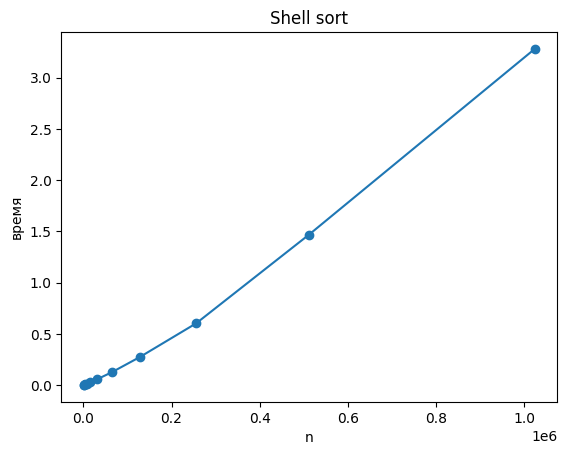

In [16]:
# АНАЛИЗ АСИМПТОТИЧЕСКОЙ СЛОЖНОСТИ
#
# - Сложность не фиксирована, зависит от последовательности шагов (gaps)
# - Смотреть сложность будем на верхнем алгоритме
# (не на том, где мы вручную задавали шаги по заданиям 1-2-34)

import matplotlib.pyplot as plt

def time_shell_sort(n):
    arr = [random.randint(1, 1000) for _ in range(n)]
    start = time.time()
    shell_sort(arr)
    end = time.time()
    result = end - start
    return result

sizes = []
for i in range(0, 10+1):
    sizes.append(2**i * 1000)
print(f"Размеры массивов: {sizes}")
times = [time_shell_sort(n) for n in sizes]

print("n\tвремя(с)")
for n, t in zip(sizes, times):
    print(f"{n}\t{t:.6f}")

plt.plot(sizes, times, 'o-')
plt.xlabel('n'); plt.ylabel('время'); plt.title('Shell sort')
plt.show()

In [17]:
# РАССЧИТЫВАЕМ СЛОЖНОСТЬ ПО АЛГОРИТМУ
#

# def shell_sort(some_list):
#     n = len(some_list)
#     gaps = gen_ciura_sequence(n)
    
#     for gap in gaps:                     # K gaps, K ≈ log n
#         for i in range(gap, n):          # n/gap проходов
#             temp = some_list[i]
#             j = i
#             while j >= gap and some_list[j - gap] > temp:     # h_k = gap сдвигов максимум
#                 some_list[j] = some_list[j - gap]
#                 j -= gap
#             some_list[j] = temp
#     return some_list

def calculate_theory(n):
    gaps = gen_ciura_sequence(n)
    total = 0
    for gap in gaps:
        passes = (n - gap) // gap + 1
        shifts_per_pass = gap // 2
        total += passes * shifts_per_pass
    print(f"T(n={n}) ≈ {total:,} операций")
    print(f"O(n^1.465) = {n**1.465:,.0f}")

def complexity_analysis():
    print("================== АНАЛИЗ СЛОЖНОСТИ ==================\n")
    
    # Временная
    print("==== АСИМПТОТИЧЕСКАЯ")
    calculate_theory(10000)
    
    # Пространственная
    print("\n==== ПРОСТРАНСТВЕННАЯ")
    print("- Переменные: temp, j, gap = O(1)")
    print("    Итого: O(1)")
    
    # Временная
    print("\n==== ВРЕМЕННАЯ:")
    print("for gap: K≈log n итераций")
    print("  for i: n/gap проходов")
    print("    while: ≤ gap сдвигов")
    print("Итого: T(n) = Σ(n/gap × gap²) = Σ(n × gap)")
    print("\nCiura: O(n^1.465)")
    print("В худшем случае: O(n²)")

complexity_analysis()


================== АНАЛИЗ СЛОЖНОСТИ ==================

==== АСИМПТОТИЧЕСКАЯ
T(n=10000) ≈ 47,214 операций
O(n^1.465) = 724,436

==== ПРОСТРАНСТВЕННАЯ
- Переменные: temp, j, gap = O(1)
    Итого: O(1)

==== ВРЕМЕННАЯ:
for gap: K≈log n итераций
  for i: n/gap проходов
    while: ≤ gap сдвигов
Итого: T(n) = Σ(n/gap × gap²) = Σ(n × gap)

Ciura: O(n^1.465)
В худшем случае: O(n²)


---

6.	**(8 баллов)**
- Проведите вычислительные эксперименты и нарисуйте графики, показывающие зависимость времени выполнения от размера входных данных n. 
    - Возьмите n равное: 100, 500, 1000, 2000, 4000, 6000, 8000, 10000. 
- Реализуйте функции для генерации следующих вариантов входных данных: 
    - a. список случайных чисел; 
    - b. отсортированный в обратную сторону список;
    - c. почти отсортированный список (один элемент в середине списка находится не на своем месте); 
    - d. половина данных равна 0, половина оставшихся 1, половина оставшихся 2 и т.д.;
    - e. первые 5% списка содержат случайные значения, а оставшиеся 95% упорядочены;
    - f. все элементы находятся в пределах 10 позиций от окончательного места в массиве.

- График зависимостей должен быть представлен для каждого варианта входных данных. 
- На каком из вариантов сортировка работает быстрее всего?
- На каком из вариантов – медленнее? 
- Как вы можете это объяснить? 

In [18]:
# ==== РЕАЛИЗУЕМ ФУНКЦИИ ГЕНЕРАЦИИ ВАРИАНТОВ ВХОДНЫХ ДАННЫХ ====================================

# - a. список случайных чисел; 
def a_gen_random(n):
    return [random.randint(1, n) for _ in range(n)]

# - b. отсортированный в обратную сторону список;
def b_gen_reverse(n):
    return list(range(n, 0, -1))

# - c. почти отсортированный список (один элемент в середине списка находится не на своем месте);
def c_gen_almost_sorted(n):
    arr = list(range(1, n+1))
    arr[n//2], arr[n//2-1] = arr[n//2-1], arr[n//2] # поменяли средние местами
    return arr

# - d. половина данных равна 0, половина оставшихся 1, половина оставшихся 2 и т.д.;
def d_gen_staircase(n):
    arr = []
    current_n = n
    i = 0
    
    while current_n > 1:
        count = current_n // 2
        arr.extend([i] * count)
        current_n //= 2
        i += 1
        
    arr.extend([i] * (n - len(arr)))
    random.shuffle(arr)
    return arr

# - e. первые 5% списка содержат случайные значения, а оставшиеся 95% упорядочены;
def e_gen_five_percent_random(n):
    arr = list(range(1, n+1))
    
    random_count = int(n * 0.05)
    randoms = [random.randint(1, n) for _ in range(random_count)]
    
    arr[:random_count] = randoms
    
    return arr

# - f. все элементы находятся в пределах 10 позиций от окончательного места в массиве.
def f_gen_ten_pos(n):
    def position(index, n):
        minim = min(index - 10, 0)
        maxim = max(index+10, n-1)
        
        pos = random.randint(minim, maxim)
        return pos
    
    arr = list(range(1, n+1))
    for i in range(n):
        pos = position(i, n)
        arr[i], arr[pos] = arr[pos], arr[i]
    return arr

# ==============================================================================================

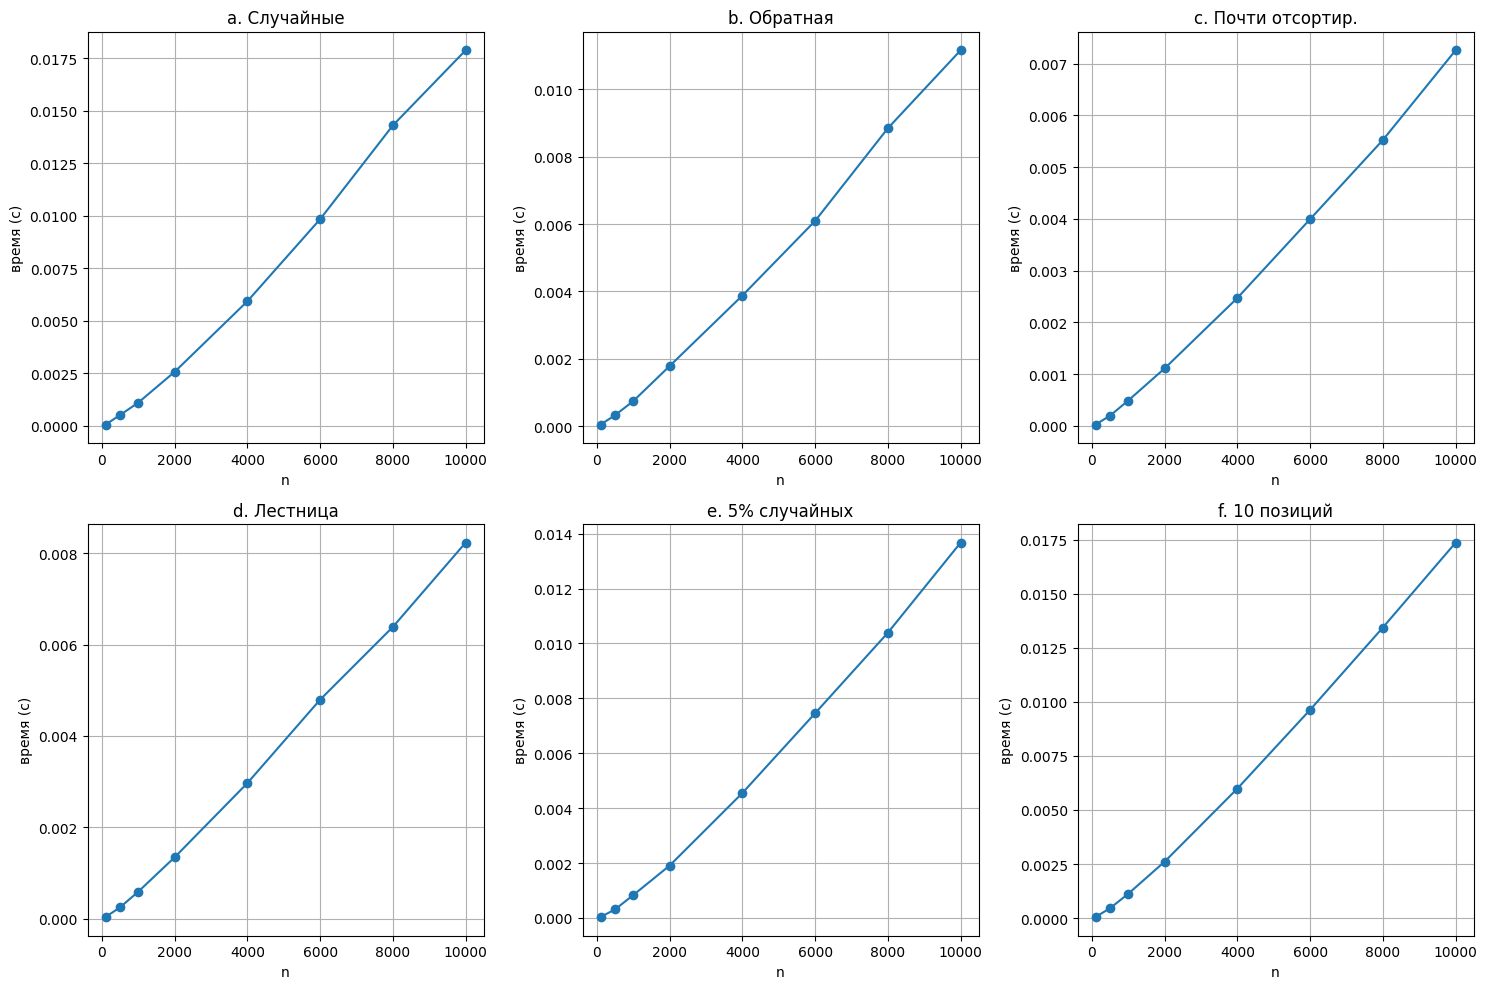


 БЫСТРЕЕ: c. Почти отсортир.
 МЕДЛЕННЕЕ: a. Случайные


In [19]:
# ======= Функция тайминга ======================================================================

def time_task8(arr):
    start = time.time()
    shell_sort(arr)
    end = time.time()
    result = end - start
    return result

# ======= ТЕСТИРУЕМ ============================================================================

sizes = [100, 500, 1000, 2000, 4000, 6000, 8000, 10000]      # из условия

generators = {
    'a. Случайные': a_gen_random,
    'b. Обратная': b_gen_reverse,
    'c. Почти отсортир.': c_gen_almost_sorted,
    'd. Лестница': d_gen_staircase,
    'e. 5% случайных': e_gen_five_percent_random,
    'f. 10 позиций': f_gen_ten_pos
}

results = {}

# для каждого генератора смотрим на всех размерах, сохраняем
for name, gen in generators.items():
    times = []
    for n in sizes:
        arr = gen(n)
        times.append(time_task8(arr))
    results[name] = times
    
# ======= ГРАФИКИ ==============================================================================
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()
for i, (name, times) in enumerate(results.items()):
    axes[i].plot(sizes, times, 'o-', label=name)
    axes[i].set_xlabel('n')
    axes[i].set_ylabel('время (с)')
    axes[i].set_title(name)
    axes[i].grid(True)
    
plt.tight_layout()
plt.show()

best_case = min(results, key=lambda k: sum(results[k]))
worst_case = max(results, key=lambda k: sum(results[k]))
print(f"\n БЫСТРЕЕ: {best_case}")
print(f" МЕДЛЕННЕЕ: {worst_case}")

In [20]:
print("\n# ======= РЕЗУЛЬТАТЫ ============================================================================")
print("n\t" + "\t".join(f"{name[:2]}" for name in results.keys()))
for i, n in enumerate(sizes):
    print(f"{n}\t" + "\t".join(f"{results[name][i]:.4f}" for name in results.keys()))
print("=================================================================================================")


# ======= РЕЗУЛЬТАТЫ ============================================================================
n	a.	b.	c.	d.	e.	f.
100	0.0000	0.0000	0.0000	0.0000	0.0000	0.0001
500	0.0005	0.0003	0.0002	0.0002	0.0003	0.0005
1000	0.0011	0.0007	0.0005	0.0006	0.0008	0.0011
2000	0.0026	0.0018	0.0011	0.0013	0.0019	0.0026
4000	0.0059	0.0039	0.0025	0.0030	0.0045	0.0060
6000	0.0098	0.0061	0.0040	0.0048	0.0075	0.0096
8000	0.0143	0.0088	0.0055	0.0064	0.0104	0.0134
10000	0.0179	0.0112	0.0073	0.0082	0.0137	0.0174


##### **КАК ЭТО ОБЪЯСНИТЬ:**
- Быстрее всего алгоритм отработал на почти отсортированных данных.
    - Это логично, буквально соответствует названию: остаётся сделать минимум шагов для завершения сортировки
- Медленее всего: список полностью случайных чисел.
    - опять же, логично, т.к. здесь полностью непредсказуемый разброс в отличии от остальных генераторов, где есть хотя бы какой-то порядок (или часть данных в определённом порядке)